# QvaPay Challenge accepted

## Requerimientos

In [41]:
import requests
import json
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from random import randint
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Exploración de datos
 

### Manejo de la base de datos

__!Warning__: En caso de que se desee correr este script por segunda vez sin cambiar los datos de consulta, se puede ejecutar la celda siguiente para leer el último archivo 'jason' almacenado localmente y pasar a la siguiente subsección. En otro caso, el usuario debe ignorar esta celda y comenzar la ejecución en la segunda.

In [ ]:
# Read JSON file
json_file_path = f'./base{current_time}.json'
with open(json_file_path, 'r') as file:
    base = json.load(file)

# Create DataFrame
base_df = pd.DataFrame(base)

Comenzamos almacenando la base de datos que solicitamos de la API de de QvaPay de transacciones P2P. Como está paginada, es necesario el uso de un bucle que sucesivamente incluye la información que solicita de la página siguiente, cuya URL nos es proporcionada en uno de los campos de cada página.

In [ ]:
base=[]
path="https://qvapay.com/api/p2p"

def get_data(path):
    response = requests.get(path)
    return response.json()

while path != None:
    data = get_data(path)
    base.extend(data['data'])
    path=data['next_page_url']

print(f'Cantidad de ofertas activas: {len(base)}')

Adicionalmente, puede resultar conveniente almacenar la base de datos localmente, debidamente etiquetada con la fecha y la hora de consulta para mayor comodidad.

In [ ]:
current_time = datetime.now()
filename_date = current_time.strftime("%Y-%m-%d_%H-%M-%S")

with open(f"base{filename_date}.json", "w") as file:
    json.dump(base, file, indent=4)

print("Base de datos salvada como "f"base{filename_date}.json")

Mudamos la base al entorno de la librería 'pandas'. Con ello disfrutaremos de una visualización más cómoda de los datos, así como de un manejo más eficiente. 

In [ ]:
base_df = pd.DataFrame(base)

Finalmente, realizamos un filtrado de la base de datos que nos permite deshacernos de los campos embebidos y datos redundantes. A partir de este momento, sobre cada entrada de la base (es decir, oferta activa en la plataforma) analizaremos:
- id único
- fecha (sin incluir hora)
- usuario
- moneda
- tipo de transacción (compra/venta)
- monto en UST
- monto que se pide (_ask_) o se ofrece (_bid_) por el monto en USDT
- precio del USDT en la transacción (el cual se calcula a partir de los últimos dos datos) 

In [ ]:
base_df["date"] = base_df["updated_at"]

filtered_base = pd.DataFrame({
    'id': base_df['uuid'],
    'date': pd.to_datetime(base_df['date']).dt.date,  # Keep only the date (first 10 characters)
    'user': base_df['owner'].apply(lambda x: x['username']),  # Extract 'name' from 'user_from'
    'coin': base_df['coin'],
    'type': base_df['type'],
    'amount': pd.to_numeric(base_df["amount"]),
    'receive': pd.to_numeric(base_df["receive"]),
})

filtered_base['price']= filtered_base["receive"]/filtered_base["amount"]
filtered_base

### Dashboard para la visualización interactiva de los datos

Se recomienda para mejorar la experiencia de usuario acompañar las siguientes secciones con la ejecución del archivo 'dashboard.py'. Se requieren para ello las librerías 'dash' y 'plotly'. Cada uno de los análisis exploratorios siguientes se visualizan en sus gráficas a partir de cálculos poco complejos.

### Análisis descriptivo de los datos

Inicialmente en el dashboard se muestra un gráfico interactivo que posibilita observar en cada fecha las ofertas activas de compra o venta en cada moneda, especificando el precio por USDT y el monto. Este gráfico permitiría análisis más específicos de estudio de tendencia, como regresiones. Otro posible estudio es relativo a la cantidad de oferta y demanda existente a diario en cada moneda, como se muestra a continuación.

In [ ]:
def plot_demand_offer_difference(filtered_base):
    # Parse dates if necessary
    filtered_base['date'] = pd.to_datetime(filtered_base['date'])

    # Group by coin and date, calculate total buy and sell amounts
    grouped = (
        filtered_base.groupby(['coin', 'date', 'type'])
        .agg(total_amount=('amount', 'sum'))
        .unstack(fill_value=0)
        .reset_index()
    )

    # Ensure columns for buy and sell exist
    if ('total_amount', 'buy') not in grouped.columns or ('total_amount', 'sell') not in grouped.columns:
        print("No buy/sell data available.")
        return

    # Calculate the difference (demand - offer)
    grouped['demand_offer_diff'] = grouped[('total_amount', 'buy')] - grouped[('total_amount', 'sell')]

    # Sort by date and filter the most recent 15 dates
    recent_data = grouped.sort_values('date', ascending=False).groupby('coin').head(15)

    # Plot
    coins = recent_data['coin'].unique()
    fig, ax = plt.subplots(figsize=(12, 8))

    for coin in coins:
        coin_data = recent_data[recent_data['coin'] == coin]
        if recent_data[recent_data['coin'] == coin].empty==False:
            ax.plot(
                coin_data['date'],
                coin_data['demand_offer_diff'],
                marker='',
                label=f"Moneda: {coin}"
            )

    # Configure plot
    ax.set_title("Diferencia diaria entre demanda y oferta", fontsize=14)
    ax.set_xlabel("Fecha", fontsize=12)
    ax.set_ylabel("Cantidad demandada en el día menos cantidad ofertada (USDT)", fontsize=12)
    ax.grid(visible=True, which='major', color='lightgrey', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, fontsize=10)
    
    # Position legend outside the axis, horizontally
    ax.legend(
        title="Monedas",
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=5,  # Number of columns in the legend
        fontsize=10
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3)  # Adjust space for legend
    plt.show()

    plt.show()

plot_demand_offer_difference(filtered_base)

Como análisis exploratorio de la circulación diaria de monedas en la plataforma, calculamos a continuación algunas medidas estadísticas generales. Estos cálculos respaldan los datos de la tabla interactiva de análisis estadístico general de las ofertas de compra/venta para cada moneda, que se encuentra en el dashboard. Son datos dinámicos (no son estáticos para cada consulta de la base de datos) y demuestran además una evidente diferencia entre la demanda (ofertas de compra) y la oferta (ofertas de venta).

In [39]:
grouped_data = (
    filtered_base
    .groupby(['coin', 'date', 'type'])
    .agg(
        total_amount=('amount', 'sum'),
        median_price=('price', 'median'),
        mean_price=('price', 'mean'),
        price_variance=('price', 'var')
    )
    .reset_index())

grouped_data

,coin,date,type,total_amount,median_price,mean_price,price_variance
0,APPLECASH,2025-01-12,buy,100.0,1.000000,1.000000,NaN
1,AXS,2024-03-10,buy,5.0,0.080300,0.080300,NaN
2,BANK,2024-05-17,buy,150.0,1.000000,1.000000,0.000000
3,BANK,2024-05-23,buy,30.0,300.000000,300.000000,NaN
4,BANK,2024-10-12,buy,2.0,350.000000,350.000000,NaN
...,...,...,...,...,...,...,...
760,ZELLE,2025-01-12,buy,100.0,1.000000,1.000000,NaN
761,ZELLE,2025-01-13,buy,745.0,1.000000,1.000000,NaN
762,ZELLE,2025-01-14,buy,200.0,1.000000,1.000000,0.000000
763,ZELLE,2025-01-14,sell,97.0,1.030928,1.030928,NaN


El análisis por usuario puede ser muy diverso. Se muestran los que poseen mayor cantidad de ofertas a su nombre disponibles en el momento de la consulta de la base de datos.

In [46]:
user_activity = (
    filtered_base
    .groupby(['user'])
    .agg(
        total_offers=('id', 'count'),
        sell_offers=('id', lambda x: x[filtered_base.loc[x.index, 'type'] == 'sell'].count()),
        buy_offers=('id', lambda x: x[filtered_base.loc[x.index, 'type'] == 'buy'].count()),
        sell_amount=('amount', lambda x: x[filtered_base.loc[x.index, 'type'] == 'sell'].sum()),
        buy_amount=('amount', lambda x: x[filtered_base.loc[x.index, 'type'] == 'buy'].sum())
    )
    .reset_index()
)

print("Mayor cantidad de ofertas activas para un usuario: ",user_activity['total_offers'].max())

user_activity[user_activity['total_offers']>= user_activity['total_offers'].max()/2]


Mayor cantidad de ofertas activas para un usuario:  8


,user,total_offers,sell_offers,buy_offers,sell_amount,buy_amount
38,Arocha88,4,0,4,0.00,33.00
67,Dayron,4,0,4,0.00,500.00
81,Ferrer,6,0,6,0.00,44.00
91,Jander,4,0,4,0.00,52.00
131,RKPLL,4,0,4,0.00,1210.00
148,Sotomay,4,0,4,0.00,439.12
174,acosta8303,7,0,7,0.00,910.00
183,adrianegil,5,0,5,0.00,312.00
189,adrielconsuegra,4,0,4,0.00,565.52
204,albertoacostaponce88,4,0,4,0.00,490.00


Otro análisis de interés por usuario es el de una posible búsqueda de recuperación de la divisa. Es característico de los Market Makers (MMs) dos fases intercaladas en el tiempo: una de acumulación y otra de liberación. Como se trata de una plataforma de ofertas activas es difícil realizar una traza de este comportamiento en el tiempo, no obstante, este análisis puede aportar sospechas sobre algunos usuarios.

Por ejemplo, se recomienda introducir en el gráfico de análisis de transacciones de los usuarios, a aquellos que se muestran en la tabla devuelta por la celda anterior.

## Inferencias de interés

Nos proponemos clasificar los usuarios de la plataforma, inicialmenete en cinco grupos:

- __Usuarios con alta tendencia a la venta en divisas de circulación internacional y compra en monedas de uso nacional.__ Esta clasificación a que la elevada actividad de un usuario en la plataforma puede deberse a la necesidad de reunir monedas en divisa de circulación internacional (ya sea para ahorrar, migrar, adquirir bienes no disponibles en monedas nacionales o negociar estas divisas en otros mercados). Estos usuarios no los claisficaremos como Market Makers.

- __Usuarios con alta tendencia a la venta en monedas de circulación nacional y compra en monedas de uso internacional.__ Esta actividad de un usuario puede estar relacionada con alguna fuente externa a la plataforma de acceso a divisas internacionales y alguna necesidad específica de monedas nacionales (por ejemplo, adquirir bienes en moneda nacional o ingresar remesas al país). Estos usuarios tampoco los clasificaremos como Market Makers.

- __Usuarios con compras y ventas en ambos grupos de monedas.__ Estos usuarios tienen más probabilidad de estar relacionados con la actividad de compra/venta de divisas como forma de ingreso, aunque no por ello necesariamente se clasificarían en Market Makers.

- __Usuarios con compras y ventas relacionadas mayormente a un solo grupo de monedas.__ Estos usuarios están en una condición similar a los anteriores, aunque no necesariamente Market Makers, tienen mayor probabilidad de serlo.

- __Usuarios con poca actividad en el mercado.__ Esta es una categoría para las personas que tienen baja actividad y por tanto no se les puede asociar con la compra/venta de divisas como forma de ingreso.

Intentaremos diferenciar estos cinco grupos a través del algoritmo K-means, para luego comparar nuestros usuarios de mayor actividad con usuarios modelos de los grupos que consideramos excluyentes. Comenzaremos diferenciando los grupos de monedas y extrayendo información de los usuarios respecto a estos grupos.

In [42]:
A = ['ETECSA', 'BOLSATM', 'RevoluPay', 'BANK_CUP', 'BANK_MLC', 'CUPCASH']  #National currencies
B = [item for item in filtered_base['coin'].unique() if item not in A]  #Other currencies

grouped_coins = []

# Iterate over each user
for user in filtered_base['user'].unique():
    user_data = filtered_base[filtered_base['user'] == user]
    
    sell_A = user_data['amount'][(user_data['coin'].isin(A)) & (user_data['type'] == 'sell')].sum()
    sell_B = user_data['amount'][(user_data['coin'].isin(B)) & (user_data['type'] == 'sell')].sum()
    buy_A = user_data['amount'][(user_data['coin'].isin(A)) & (user_data['type'] == 'buy')].sum()
    buy_B = user_data['amount'][(user_data['coin'].isin(B)) & (user_data['type'] == 'buy')].sum()
    sell_amount = user_data[user_data['type'] == 'sell'].shape[0]
    buy_amount = user_data[user_data['type'] == 'buy'].shape[0]
    offers_A = user_data[user_data['coin'].isin(A)].shape[0]
    offers_B = user_data[user_data['coin'].isin(B)].shape[0]
    active_days = len(user_data['date'].unique())
    
    grouped_coins.append({
        'user': user,
        'sell_A': sell_A,
        'sell_B': sell_B,
        'buy_A': buy_A,
        'buy_B': buy_B,
        'sell_amount': sell_amount,
        'buy_amount': buy_amount,
        'offers_A': offers_A,
        'offers_B': offers_B,
        'active_days': active_days
    })

grouped_coins = pd.DataFrame(grouped_coins)

# Reset index to ensure the DataFrame is clean
grouped_coins.reset_index(drop=True, inplace=True)

Aplicaremos el algoritmo K-means con cinco clusters. Nuestra idea será comparar nuestros usuarios con usuarios modelos que insertamos pensando en los grupos 1, 2 y 5, que creemos que son excluyentes.

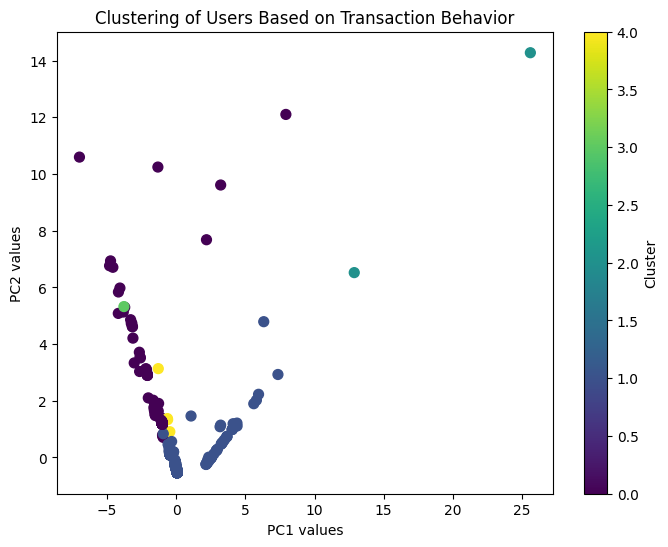

In [57]:
# Create derived features (ratios for cross-group trades)
grouped_coins['A_to_B_ratio'] = grouped_coins['sell_A'] / (grouped_coins['buy_B'] + 1e-6)
grouped_coins['B_to_A_ratio'] = grouped_coins['sell_B'] / (grouped_coins['buy_A'] + 1e-6)

# Select features for clustering
features = grouped_coins[['sell_A', 'sell_B', 'buy_A', 'buy_B', 'sell_amount', 'buy_amount', 'active_days']]

# Normalize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

# Add cluster labels to the dataset
grouped_coins['Cluster'] = clusters

# Visualize clusters in 2D using PCA
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(scaled_features)

plt.figure(figsize=(8, 6))
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=clusters, cmap='viridis', s=50)
plt.title("Clustering of Users Based on Transaction Behavior")
plt.xlabel("PC1 values")
plt.ylabel("PC2 values")
plt.colorbar(label="Cluster")
plt.show()

Visualizamos la data clasificada para encontrar patrones que nos puedan ayudar a encontrar a clasificar a primera vista los clusters obtenidos. En un ejercicio con mayor disponibilidad de tiempo, se utilizaría más de un K-means para clasificar la data, y/o se añadirían usuarios modelos que agrupen los datos a su alrededor. También se pueden hacer distintos ajustes de parámetros.

In [56]:
grouped_coins[grouped_coins['Cluster']==0]

,user,sell_A,sell_B,buy_A,buy_B,sell_amount,buy_amount,offers_A,offers_B,active_days,A_to_B_ratio,B_to_A_ratio,Cluster
3,erikrusia52@gmail.com,59.00,0.0,0.0,1695.0,1,5,1,5,6,3.480826e-02,0.0,0
12,axelronald0104,0.00,0.0,440.0,0.0,0,7,7,0,1,0.000000e+00,0.0,0
18,osmanisarda90,0.00,0.0,1300.0,0.0,0,6,6,0,1,0.000000e+00,0.0,0
21,maurisyenery,99.75,0.0,500.0,0.0,1,5,6,0,3,9.975000e+07,0.0,0
24,$idney,0.00,0.0,182.0,0.0,0,2,2,0,2,0.000000e+00,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,ydiazdedios,0.00,0.0,47.0,0.0,0,2,2,0,2,0.000000e+00,0.0,0
998,RKPLL,0.00,0.0,1210.0,0.0,0,4,4,0,1,0.000000e+00,0.0,0
1013,traviesocu97,0.00,0.0,200.0,0.0,0,2,2,0,2,0.000000e+00,0.0,0
1016,eliezer98,0.00,0.0,200.0,0.0,0,2,2,0,2,0.000000e+00,0.0,0


In [52]:
grouped_coins[grouped_coins['Cluster']==1]

,user,sell_A,sell_B,buy_A,buy_B,sell_amount,buy_amount,offers_A,offers_B,active_days,A_to_B_ratio,B_to_A_ratio,Cluster
0,fastcash,18.31,0.0,0.0,0.0,2,0,2,0,1,18310000.0,0.0,1
1,222javimaxstudio,59.00,0.0,0.0,0.0,1,0,1,0,1,59000000.0,0.0,1
2,mrodriguez930305,0.00,0.0,12.0,0.0,0,2,2,0,1,0.0,0.0,1
6,benigno.triana,0.00,0.0,30.0,0.0,0,1,1,0,1,0.0,0.0,1
7,yasperking1,0.00,0.0,5.0,0.0,0,1,1,0,1,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032,redmaniac2020,0.00,0.0,21.0,0.0,0,1,1,0,1,0.0,0.0,1
1034,David98Romero,0.00,0.0,12.0,0.0,0,1,1,0,1,0.0,0.0,1
1035,owenxbit,0.00,0.0,10.0,0.0,0,1,1,0,1,0.0,0.0,1
1036,encno22,0.00,0.0,452.0,0.0,0,1,1,0,1,0.0,0.0,1


In [53]:
grouped_coins[grouped_coins['Cluster']==2]

,user,sell_A,sell_B,buy_A,buy_B,sell_amount,buy_amount,offers_A,offers_B,active_days,A_to_B_ratio,B_to_A_ratio,Cluster
5,alsomesi1981,200.0,0.0,0.0,0.0,3,0,3,0,1,200000000.0,0.0,2
13,guillermito,330.0,0.0,0.0,0.0,8,0,8,0,1,330000000.0,0.0,2


In [54]:
grouped_coins[grouped_coins['Cluster']==3]

,user,sell_A,sell_B,buy_A,buy_B,sell_amount,buy_amount,offers_A,offers_B,active_days,A_to_B_ratio,B_to_A_ratio,Cluster
4,Vagabond_dude,0.0,800.0,0.0,0.0,3,0,0,3,2,0.0,800000000.0,3
26,ydominguezcrespo,0.0,2500.0,2500.0,0.0,3,3,3,3,2,0.0,1.0,3
94,juliodeniscastillo14,0.0,521.0,0.0,0.0,1,0,0,1,1,0.0,521000000.0,3
139,rabad.ssl,0.0,500.0,0.0,0.0,1,0,0,1,1,0.0,500000000.0,3


In [55]:
grouped_coins[grouped_coins['Cluster']==4]

,user,sell_A,sell_B,buy_A,buy_B,sell_amount,buy_amount,offers_A,offers_B,active_days,A_to_B_ratio,B_to_A_ratio,Cluster
804,carrazana920220,0.0,0.0,0.0,14500.0,0,2,0,2,2,0.0,0.0,4


__Algoritmo de clasificación de Market Makers__

Proponemos el siguiente algoritmo para identificar Market Makers:
- Inicialmente desechar los usuarios que solo compran o venden.
- Emplear un K-Means que identifique los usuarios de baja actividad, por ejemplo, que se base principalemente en los features: cantidad de ofertas, días de actividad.
- Emplear el K-Means mostrado para separar en los grupos 1 y 2, y 3 y 4. Nuestro interés estará en el 3 y el 4. Puede ser un K-means de dos o cuatro clusters, según disponibilidad de data. Identificamos introduciendo artificialmente usuarios modelos (que tienen el comportamiento esperando de cada uno de los grupos).
- Calcular el _spread_. En este caso no hay suficiente data para que sea relamente efectivo, pero en otros contextos se puede calcular el _spread_ mínimo entre todos los usuarios con compras y ventas en cada moneda. El de los verdaderos Market Makers no debe ser distante.

A continuación se ofrecen una función para calcular el _spread_ de los Market Makers.

In [59]:
def calculate_mean_price_difference(filtered_base, coin, specific_date, user=None):
    """
    Calculate the mean difference between sell prices and buy prices for a specific user, coin, and date.

    Parameters:
        filtered_base (pd.DataFrame): The transactions dataset.
        coin (str): The coin to filter by (e.g., 'BTC').
        specific_date (str): The specific date to filter by (e.g., '2023-01-01').
        user (str, optional): The user to filter by. If None, considers all users.

    Returns:
        pd.DataFrame: A DataFrame showing the mean price difference for the specified filters.
    """
    # Apply filters
    filtered_data = filtered_base[
        (filtered_base['coin'] == coin) & (filtered_base['date'] == specific_date)
    ]
    if user:
        filtered_data = filtered_data[filtered_data['user'] == user]

    if filtered_data.empty:
        return pd.DataFrame(columns=['user', 'coin', 'mean_buy_price', 'mean_sell_price', 'mean_price_difference'])

    # Separate buy and sell transactions
    buy_prices = filtered_data[filtered_data['type'] == 'buy'].groupby(['user', 'coin'])['price'].mean().reset_index()
    sell_prices = filtered_data[filtered_data['type'] == 'sell'].groupby(['user', 'coin'])['price'].mean().reset_index()

    # Rename columns for clarity
    buy_prices.rename(columns={'price': 'mean_buy_price'}, inplace=True)
    sell_prices.rename(columns={'price': 'mean_sell_price'}, inplace=True)

    # Merge buy and sell data on user and coin
    price_diff = pd.merge(buy_prices, sell_prices, on=['user', 'coin'], how='outer')

    # Calculate the mean price difference (sell - buy)
    price_diff['mean_price_difference'] = price_diff['mean_sell_price'] - price_diff['mean_buy_price']

    # Fill NaN values with 0 for cases where there are no buy or sell transactions
    price_diff.fillna({'mean_buy_price': 0, 'mean_sell_price': 0, 'mean_price_difference': 0}, inplace=True)

    return price_diff

## Algunas conclusiones

- Determinar qué interacciones en un mercado de divisas están asociadas a una actividad de _trading_ puede ser sumamente complejo, pues hay que tener en cuenta no solo las interacciones de los usuarios sino también la naturaleza de las monedas que se mueven.
- El resultado del algoritmo de clusterización K-means es difícil de interpretar cuando se solicitan varios clusters, por lo que es preferible realizar más de uno.
- La data solo posee ofertas activas, por lo que no es posible analizar las fases de acumulación y liberación de las divisas que son características de los Market Makers.
- La información de la base evidencia una demanda de USDT muy superior a la oferta, por lo que el spread pequeño no tiene por qué ser una característica obligatoria de los Market Makers, pues pueden generar ganancias sin restar liquidez al mercado.